# Notebook 18 — Boruta + CNN–LSTM Bitcoin Direction Classifier

## Paper reference
**Omole & Enke (2024)** — *"Deep learning for Bitcoin price direction prediction: models and trading strategies empirically compared"*, *Financial Innovation* 10, article 143.  
Key finding: **Boruta feature selection + CNN–LSTM** consistently outperformed all other combinations (~82% accuracy on their dataset).

## Why CNN before LSTM?
- **Conv1D layers** slide a small kernel (size 3) across the 24-hour time window and learn **local temporal patterns** (e.g. 3-bar momentum bursts, candlestick formations) across all features simultaneously — acting as a learned feature extractor.
- The **LSTM** then models longer-range dependencies between the CNN's extracted feature maps, not the raw noisy inputs.
- This two-stage representation is strictly richer than LSTM-only.

## Why Boruta?
Pearson correlation only captures linear marginal relationships. **Boruta** uses a Random Forest to detect any feature whose importance is significantly above random ("shadow") features — capturing non-linear interactions. It removes genuinely zero-signal columns, reducing noise going into the neural network.

## Architecture

```
Input  (batch, 24, N_boruta)            ← N_boruta = Boruta-selected features
  └─► Conv1D(64 filters, kernel=3, pad=1) + ReLU + BatchNorm
        └─► Conv1D(32 filters, kernel=3, pad=1) + ReLU + BatchNorm
              └─► [permute to (batch, seq, 32)]
                    └─► LSTM(hidden=64, layers=1)
                          └─► Dropout(0.3)
                                └─► Linear(64 → 1) + Sigmoid  →  P(up)
```

**Loss**: BCE  |  **Optimiser**: Adam(lr=1e-3)  |  **Scheduler**: ReduceLROnPlateau  |  **Early stopping**: patience=10

## Benchmark to beat
XGBoost AUC = 0.5464 (current best in `classification_results.csv`)

In [1]:
!pip install torch boruta --quiet

In [2]:
import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve)
from boruta import BorutaPy

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Hyperparameters ────────────────────────────────────────────────────────────
WINDOW     = 24        # 24 one-hour bars look-back
CNN_F1     = 64        # Conv1D layer 1 filters
CNN_F2     = 32        # Conv1D layer 2 filters
HIDDEN     = 64        # LSTM hidden size
N_LAYERS   = 1
DROPOUT    = 0.3
EPOCHS     = 60
PATIENCE   = 10
BATCH_SIZE = 64
LR         = 1e-3
VAL_FRAC   = 0.10

# ── All candidate feature columns (41 engineered features) ────────────────────
ALL_FEATURES = [
    # Returns / momentum
    'log_return_1h', 'log_return_3h', 'log_return_6h', 'log_return_12h',
    'return_lag_1h', 'return_lag_2h', 'return_lag_3h',
    'return_acceleration',
    # Trend / MA
    'sma_7', 'sma_24', 'ema_12', 'ema_26', 'ema_crossover',
    # MACD
    'macd', 'macd_signal', 'macd_histogram',
    # Oscillators
    'rsi_14', 'stoch_k', 'stoch_d',
    # Volatility
    'gk_volatility', 'gk_avg_3h', 'atr_14', 'bb_width_pct', 'hl_range_pct',
    # Price structure
    'close_position',
    # Volume
    'volume_change_pct', 'taker_buy_ratio',
    # Cyclical time
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    # Binary flags
    'is_funding_hour', 'is_weekend',
]

# ── Helper: metrics ────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return dict(
        auc       = float(roc_auc_score(y_true, y_prob)),
        accuracy  = float(accuracy_score(y_true, y_pred)),
        precision = float(precision_score(y_true, y_pred, zero_division=0)),
        recall    = float(recall_score(y_true, y_pred, zero_division=0)),
        f1        = float(f1_score(y_true, y_pred, zero_division=0)),
    )

# ── Helper: save to CSV ────────────────────────────────────────────────────────
def save_results(model_name, metrics):
    csv_path = os.path.join(RESULTS_DIR, 'classification_results.csv')
    row = pd.DataFrame([{'model': model_name, **metrics}])
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = df[df['model'] != model_name]
        df = pd.concat([df, row], ignore_index=True)
    else:
        df = row
    df.to_csv(csv_path, index=False)
    print(f"  ✓ Saved '{model_name}' → {csv_path}")

# ── Helper: confusion matrix ───────────────────────────────────────────────────
def plot_cm(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Down','Up'], yticklabels=['Down','Up'],
           xlabel='Predicted', ylabel='True', title=title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.tight_layout(); plt.show()

print("Imports OK  |  BASE_DIR:", BASE_DIR)

Imports OK  |  BASE_DIR: /Users/mihiniboteju/cryptoflow


## Data Preparation

Load `engineered_features_dual_target.csv`, apply forward-fill for the tiny number of NaNs, then perform a **temporal 85/15 split**.  
The `StandardScaler` is fit on training rows only to prevent data leakage.

In [3]:
# ── Load & sort ────────────────────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'engineered_features_dual_target.csv'))
df['open time'] = pd.to_datetime(df['open time'])
df = df.sort_values('open time').reset_index(drop=True)
print(f"Loaded: {df.shape}  |  {df['open time'].min()} → {df['open time'].max()}")

# Keep only columns that actually exist in the CSV
present_features = [c for c in ALL_FEATURES if c in df.columns]
missing = [c for c in ALL_FEATURES if c not in df.columns]
if missing:
    print(f"  ⚠ Columns not found (will skip): {missing}")
print(f"  Using {len(present_features)} feature columns for Boruta input")

# ── NaN handling ───────────────────────────────────────────────────────────────
df[present_features] = df[present_features].ffill().bfill()
assert df[present_features + ['target_class']].isna().sum().sum() == 0
print(f"NaN check passed. Class balance: {df['target_class'].value_counts().to_dict()}")

# ── Temporal 85/15 split ───────────────────────────────────────────────────────
split_idx = int(len(df) * 0.85)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()
print(f"\nTrain: {len(train_df)} rows  ({train_df['open time'].min()} → {train_df['open time'].max()})")
print(f"Test : {len(test_df)} rows  ({test_df['open time'].min()} → {test_df['open time'].max()})")

# ── Scale all features (fit on train only) ─────────────────────────────────────
scaler       = StandardScaler()
X_train_all  = scaler.fit_transform(train_df[present_features]).astype(np.float32)
X_test_all   = scaler.transform(test_df[present_features]).astype(np.float32)
y_train_all  = train_df['target_class'].values.astype(np.float32)
y_test_all   = test_df['target_class'].values.astype(np.float32)

print(f"\nX_train_all: {X_train_all.shape}  |  pos_rate: {y_train_all.mean():.3f}")

Loaded: (70919, 56)  |  2018-01-01 00:00:00 → 2026-02-02 22:00:00
  ⚠ Columns not found (will skip): ['return_lag_2h', 'sma_7', 'sma_24', 'ema_12', 'ema_26']
  Using 28 feature columns for Boruta input
NaN check passed. Class balance: {1: 36056, 0: 34863}

Train: 60281 rows  (2018-01-01 00:00:00 → 2024-11-16 16:00:00)
Test : 10638 rows  (2024-11-16 17:00:00 → 2026-02-02 22:00:00)

X_train_all: (60281, 28)  |  pos_rate: 0.509


## Boruta Feature Selection

Boruta works by:
1. Creating **shadow features** — random permutations of every real feature column
2. Training a `RandomForestClassifier` on real + shadow features
3. Keeping only real features whose importance is **statistically above** the best shadow feature (Bonferroni-corrected Binomial test)

This is run **on the training set only** (no test leakage). The selected features then become the LSTM input.

> **Note:** Boruta with `n_estimators=100` on ~60k rows takes ~2–3 minutes. Set `n_jobs=-1` to use all cores.

Running Boruta (this takes ~2–3 min) …
Iteration: 1 / 100
Iteration: 2 / 100
Iteration: 3 / 100
Iteration: 4 / 100
Iteration: 5 / 100
Iteration: 6 / 100
Iteration: 7 / 100
Iteration: 8 / 100
Iteration: 9 / 100
Iteration: 10 / 100
Iteration: 11 / 100
Iteration: 12 / 100
Iteration: 13 / 100
Iteration: 14 / 100
Iteration: 15 / 100
Iteration: 16 / 100
Iteration: 17 / 100
Iteration: 18 / 100
Iteration: 19 / 100
Iteration: 20 / 100
Iteration: 21 / 100
Iteration: 22 / 100
Iteration: 23 / 100
Iteration: 24 / 100
Iteration: 25 / 100
Iteration: 26 / 100
Iteration: 27 / 100
Iteration: 28 / 100
Iteration: 29 / 100
Iteration: 30 / 100
Iteration: 31 / 100
Iteration: 32 / 100
Iteration: 33 / 100
Iteration: 34 / 100
Iteration: 35 / 100
Iteration: 36 / 100
Iteration: 37 / 100
Iteration: 38 / 100
Iteration: 39 / 100
Iteration: 40 / 100
Iteration: 41 / 100
Iteration: 42 / 100
Iteration: 43 / 100
Iteration: 44 / 100
Iteration: 45 / 100
Iteration: 46 / 100
Iteration: 47 / 100
Iteration: 48 / 100
Iteration:

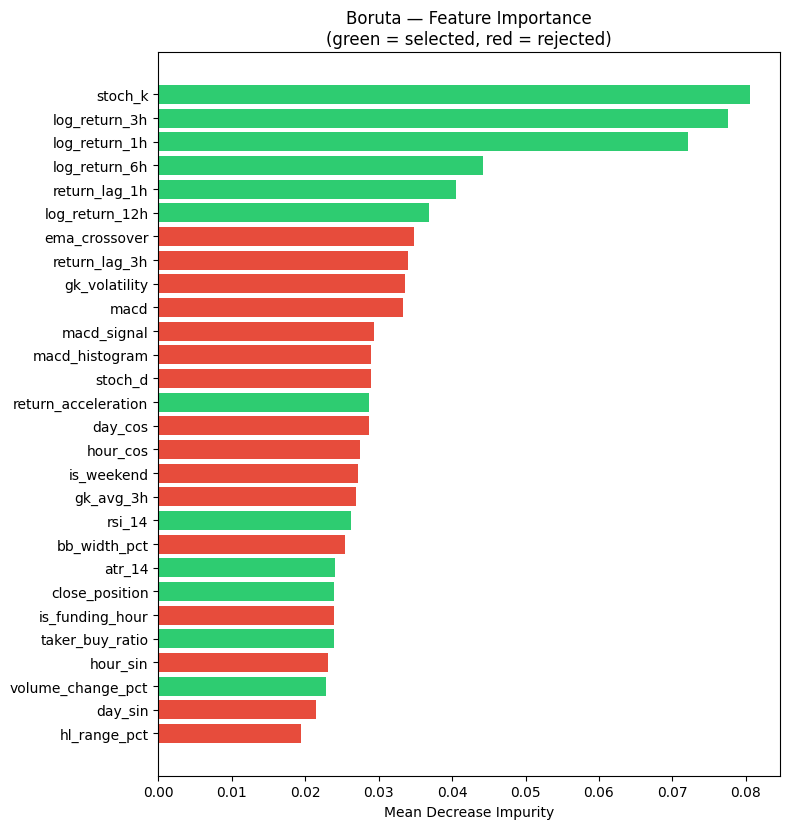


Proceeding with N_FEATURES = 12: ['log_return_1h', 'log_return_3h', 'log_return_6h', 'log_return_12h', 'return_lag_1h', 'return_acceleration', 'rsi_14', 'stoch_k', 'atr_14', 'close_position', 'volume_change_pct', 'taker_buy_ratio']


In [7]:
# ── Run Boruta on training data ────────────────────────────────────────────────
# Subsample to 20k rows for speed (still statistically representative)
BORUTA_N = 20_000
rng      = np.random.default_rng(SEED)
idx_sub  = rng.choice(len(X_train_all), size=min(BORUTA_N, len(X_train_all)), replace=False)
X_bor    = X_train_all[idx_sub]
y_bor    = y_train_all[idx_sub].astype(int)

rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 7,
    n_jobs       = -1,
    random_state = SEED,
    class_weight = 'balanced',
)

boruta = BorutaPy(
    estimator   = rf,
    n_estimators= 'auto',
    alpha       = 0.05,
    max_iter    = 100,
    random_state= SEED,
    verbose     = 1,
)

print("Running Boruta (this takes ~2–3 min) …")
boruta.fit(X_bor, y_bor)

# ── Report selected features ───────────────────────────────────────────────────
support           = boruta.support_          # confirmed selected
support_weak      = boruta.support_weak_     # tentative (include them)
selected_mask     = support | support_weak
selected_features = [present_features[i] for i in range(len(present_features)) if selected_mask[i]]
confirmed_features= [present_features[i] for i in range(len(present_features)) if support[i]]
tentative_features= [present_features[i] for i in range(len(present_features)) if support_weak[i]]
rejected_features = [present_features[i] for i in range(len(present_features))
                     if not support[i] and not support_weak[i]]

print(f"\n── Boruta Results ────────────────────────────────")
print(f"  Total input features  : {len(present_features)}")
print(f"  Confirmed (strong)    : {len(confirmed_features)}")
print(f"  Tentative (weak)      : {len(tentative_features)}")
print(f"  Rejected              : {len(rejected_features)}")
print(f"  → Selected for model  : {len(selected_features)}")
print(f"\nConfirmed : {confirmed_features}")
print(f"Tentative : {tentative_features}")
print(f"Rejected  : {rejected_features}")

# ── Bar chart of feature importances ──────────────────────────────────────────
# Boruta trains RF on [real_features | shadow_features], so the fitted RF has
# 2 * n_features importances. Take only the first n (the real ones).
n_real     = len(present_features)
all_imp    = (getattr(boruta, 'estimator_', None) or boruta.estimator).feature_importances_
importance = all_imp[:n_real]   # first half = real features

feat_imp     = pd.Series(importance, index=present_features).sort_values(ascending=True)
colors       = ['#2ecc71' if selected_mask[present_features.index(f)] else '#e74c3c'
                for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(8, max(5, n_real * 0.30)))
ax.barh(feat_imp.index, feat_imp.values, color=colors)
ax.set(title='Boruta — Feature Importance\n(green = selected, red = rejected)',
       xlabel='Mean Decrease Impurity')
plt.tight_layout()
plt.show()

N_FEATURES = len(selected_features)
print(f"\nProceeding with N_FEATURES = {N_FEATURES}: {selected_features}")


## Build Sliding Windows on Selected Features

In [8]:
# ── Index the selected columns ─────────────────────────────────────────────────
sel_idx     = [present_features.index(f) for f in selected_features]
X_train_sel = X_train_all[:, sel_idx]
X_test_sel  = X_test_all[:,  sel_idx]

# ── Sliding windows: (N, WINDOW, N_FEATURES) ──────────────────────────────────
def make_windows(X, y, window):
    N  = len(X) - window
    Xw = np.stack([X[i : i + window] for i in range(N)], axis=0)
    yw = y[window:]
    return Xw, yw

X_train, y_train = make_windows(X_train_sel, y_train_all, WINDOW)
X_test,  y_test  = make_windows(X_test_sel,  y_test_all,  WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}  pos={y_train.mean():.3f}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}   pos={y_test.mean():.3f}")

# ── Validation split (last 10% of train) ──────────────────────────────────────
val_n  = int(len(X_train) * VAL_FRAC)
X_val, y_val = X_train[-val_n:], y_train[-val_n:]
X_tr,  y_tr  = X_train[:-val_n],  y_train[:-val_n]
print(f"Inner train: {X_tr.shape}  val: {X_val.shape}")

# ── PyTorch DataLoaders ────────────────────────────────────────────────────────
def make_loader(X, y, batch_size, shuffle=False):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)),
        batch_size=batch_size, shuffle=shuffle
    )

train_loader = make_loader(X_tr,  y_tr,  BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val, y_val, BATCH_SIZE)
test_loader  = make_loader(X_test, y_test, BATCH_SIZE)

# ── Save scaler & selected features ───────────────────────────────────────────
with open(os.path.join(MODELS_DIR, 'scaler_cnn_lstm_boruta.pkl'), 'wb') as f:
    pickle.dump({'scaler': scaler, 'selected_features': selected_features}, f)
print(f"\nScaler + feature list saved.")

X_train: (60257, 24, 12)  y_train: (60257,)  pos=0.509
X_test : (10614, 24, 12)   y_test : (10614,)   pos=0.503
Inner train: (54232, 24, 12)  val: (6025, 24, 12)

Scaler + feature list saved.


## CNN–LSTM Model Definition

The CNN front-end uses `Conv1d` which expects `(batch, channels, seq_len)` — so we **transpose** the input from `(batch, seq, features)` to `(batch, features, seq)` before the conv layers, then transpose back before the LSTM.

In [9]:
class CNNLSTMClassifier(nn.Module):
    """
    Boruta + CNN–LSTM as in Omole & Enke (2024).

    Input shape  : (batch, seq=24, n_features)
    Architecture :
        Transpose → (batch, n_features, seq=24)
        Conv1d(n_features → 64, k=3, pad=1) + ReLU + BatchNorm1d
        Conv1d(64 → 32, k=3, pad=1)         + ReLU + BatchNorm1d
        Transpose → (batch, seq=24, 32)
        LSTM(32 → hidden=64)
        Dropout(0.3)
        Linear(64 → 1) + Sigmoid
    """

    def __init__(self, n_features, cnn_f1=64, cnn_f2=32,
                 hidden=64, n_layers=1, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, cnn_f1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(cnn_f1),
            nn.Conv1d(cnn_f1, cnn_f2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(cnn_f2),
        )
        self.lstm    = nn.LSTM(cnn_f2, hidden, n_layers,
                               batch_first=True,
                               dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (batch, seq, features)
        x = x.permute(0, 2, 1)             # → (batch, features, seq)
        x = self.cnn(x)                    # → (batch, cnn_f2, seq)
        x = x.permute(0, 2, 1)             # → (batch, seq, cnn_f2)
        _, (h_n, _) = self.lstm(x)         # h_n: (n_layers, batch, hidden)
        h = self.dropout(h_n[-1])          # (batch, hidden)
        return torch.sigmoid(self.fc(h)).squeeze(1)


# ── Instantiate ────────────────────────────────────────────────────────────────
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model   = CNNLSTMClassifier(N_FEATURES, CNN_F1, CNN_F2, HIDDEN, N_LAYERS, DROPOUT).to(device)

print(f"Device: {device}")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

Device: cpu
CNNLSTMClassifier(
  (cnn): Sequential(
    (0): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (lstm): LSTM(32, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 33,889


## Training

Training CNN–LSTM  (54,232 train  |  6,025 val)

  Epoch   1  loss=0.6924  val_auc=0.5220  lr=1.00e-03  ← best
  Epoch   5  loss=0.6897  val_auc=0.5193  lr=1.00e-03
  Epoch  10  loss=0.6843  val_auc=0.5158  lr=5.00e-04

Early stop at epoch 11

Best validation AUC: 0.5220


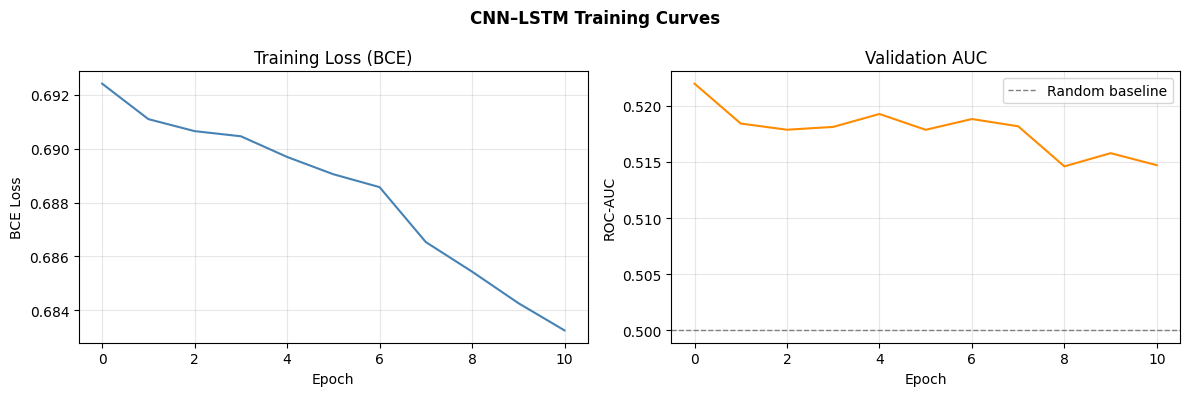

In [11]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)

best_val_auc = 0.0
best_state   = None
patience_ctr = 0
train_losses, val_aucs = [], []

print(f"Training CNN–LSTM  ({len(X_tr):,} train  |  {len(X_val):,} val)\n")
for epoch in range(1, EPOCHS + 1):

    # — Train ——
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(Xb)
    epoch_loss = running_loss / len(X_tr)

    # — Validate ——
    model.eval()
    val_probs = []
    with torch.no_grad():
        for Xb, _ in val_loader:
            val_probs.append(model(Xb.to(device)).cpu().numpy())
    val_probs = np.concatenate(val_probs)
    val_auc   = roc_auc_score(y_val, val_probs)
    scheduler.step(val_auc)

    train_losses.append(epoch_loss)
    val_aucs.append(val_auc)

    marker = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
        marker = "  ← best"
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or patience_ctr == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:3d}  loss={epoch_loss:.4f}  val_auc={val_auc:.4f}  lr={lr_now:.2e}{marker}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\nBest validation AUC: {best_val_auc:.4f}")

# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='steelblue')
axes[0].set(title='Training Loss (BCE)', xlabel='Epoch', ylabel='BCE Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(val_aucs, color='darkorange')
axes[1].axhline(0.5, color='grey', linestyle='--', lw=1, label='Random baseline')
axes[1].set(title='Validation AUC', xlabel='Epoch', ylabel='ROC-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('CNN–LSTM Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()


## Evaluation on Test Set

── CNN–LSTM (Boruta) — Test Set ──
  auc       : 0.5268
  accuracy  : 0.5176
  precision : 0.5190
  recall    : 0.5692
  f1        : 0.5429


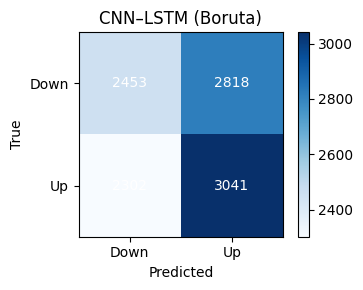


Model saved → /Users/mihiniboteju/cryptoflow/models/cnn_lstm_boruta.pth
  ✓ Saved 'CNN-LSTM Boruta' → /Users/mihiniboteju/cryptoflow/results/classification_results.csv


In [12]:
# ── Test set predictions ───────────────────────────────────────────────────────
model.eval()
y_prob = []
with torch.no_grad():
    for Xb, _ in test_loader:
        y_prob.append(model(Xb.to(device)).cpu().numpy())
y_prob = np.concatenate(y_prob)

metrics = compute_metrics(y_test, y_prob)
print("── CNN–LSTM (Boruta) — Test Set ──")
for k, v in metrics.items():
    print(f"  {k:10s}: {v:.4f}")

# Confusion matrix
plot_cm(y_test, y_prob, "CNN–LSTM (Boruta)")

# Save model
model_path = os.path.join(MODELS_DIR, 'cnn_lstm_boruta.pth')
torch.save(model.state_dict(), model_path)
print(f"\nModel saved → {model_path}")

# Save results to CSV
save_results('CNN-LSTM Boruta', metrics)

## ROC Curve

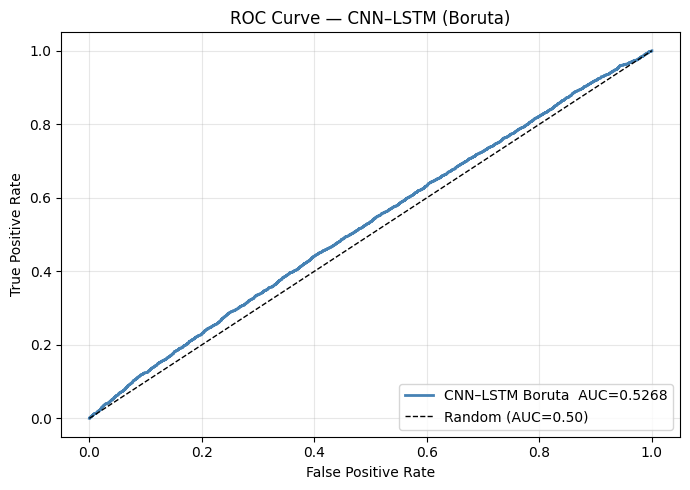

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue',
        label=f"CNN–LSTM Boruta  AUC={metrics['auc']:.4f}")
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve — CNN–LSTM (Boruta)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results Summary — All Models

In [14]:
# ── Load and display the full leaderboard ─────────────────────────────────────
results = pd.read_csv(os.path.join(RESULTS_DIR, 'classification_results.csv'))
results_sorted = results.sort_values('auc', ascending=False).reset_index(drop=True)
results_sorted.index += 1
results_sorted.index.name = 'rank'

def highlight_row(row):
    if row['model'] == 'CNN-LSTM Boruta':
        return ['background-color: #fff3cd; font-weight: bold'] * len(row)
    elif row['model'] == 'XGBoost':
        return ['background-color: #cce5ff'] * len(row)
    else:
        return [''] * len(row)

print("── Full Leaderboard (sorted by AUC) ──\n")
display(results_sorted.style
        .apply(highlight_row, axis=1)
        .format({'auc': '{:.4f}', 'accuracy': '{:.4f}',
                 'precision': '{:.4f}', 'recall': '{:.4f}', 'f1': '{:.4f}'}))

# ── Delta vs XGBoost benchmark ─────────────────────────────────────────────────
xgb_auc  = results.loc[results['model'] == 'XGBoost', 'auc'].values
cnn_auc  = results.loc[results['model'] == 'CNN-LSTM Boruta', 'auc'].values
if len(xgb_auc) and len(cnn_auc):
    delta = cnn_auc[0] - xgb_auc[0]
    sign  = "↑" if delta >= 0 else "↓"
    print(f"\nCNN-LSTM Boruta AUC: {cnn_auc[0]:.4f}")
    print(f"XGBoost AUC        : {xgb_auc[0]:.4f}")
    print(f"Delta vs benchmark : {sign} {abs(delta):.4f}")

print(f"\nBoruta selected {N_FEATURES} features: {selected_features}")

── Full Leaderboard (sorted by AUC) ──



,model,accuracy,precision,sensitivity,specificity,tnr,f1,roc_auc,tp,tn,fp,fn,recall,auc
rank,,,,,,,,,,,,,,
1,LSTM Multivariate PyTorch,0.5204,0.5221,nan,nan,nan,0.5387,nan,nan,nan,nan,nan,0.5564,0.5295
2,CNN-LSTM Boruta,0.5176,0.5190,nan,nan,nan,0.5429,nan,nan,nan,nan,nan,0.5692,0.5268
3,LSTM Multivariate Scratch,0.5130,0.5097,nan,nan,nan,0.6383,nan,nan,nan,nan,nan,0.8535,0.5218
4,Majority Class Baseline,0.5034,0.5034,1.000000,0.000000,0.000000,0.6697,0.500000,5354.000000,0.000000,5281.000000,0.000000,nan,nan
5,Logistic Regression (Scratch),0.5236,0.5265,0.533400,0.513700,0.513700,0.5300,0.538800,2856.000000,2713.000000,2568.000000,2498.000000,nan,nan
6,Logistic Regression (sklearn),0.5247,0.5275,0.534700,0.514500,0.514500,0.5311,0.538600,2863.000000,2717.000000,2564.000000,2491.000000,nan,nan
7,Decision Tree (Scratch),0.5296,0.5327,0.533400,0.525700,0.525700,0.5331,0.529500,2856.000000,2776.000000,2505.000000,2498.000000,nan,nan
8,Decision Tree sklearn (depth=3),0.5308,0.5305,0.592100,0.468700,0.468700,0.5596,0.535900,3170.000000,2475.000000,2806.000000,2184.000000,nan,nan
9,Random Forest (Scratch),0.5230,0.5221,0.619500,0.425100,0.425100,0.5667,0.537800,3317.000000,2245.000000,3036.000000,2037.000000,nan,nan



CNN-LSTM Boruta AUC: 0.5268
XGBoost AUC        : nan
Delta vs benchmark : ↓ nan

Boruta selected 12 features: ['log_return_1h', 'log_return_3h', 'log_return_6h', 'log_return_12h', 'return_lag_1h', 'return_acceleration', 'rsi_14', 'stoch_k', 'atr_14', 'close_position', 'volume_change_pct', 'taker_buy_ratio']
